In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import pickle

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
df = pd.read_csv('credit_risk_dataset.csv.zip')
print('Dataset Shape:', df.shape)
df.head()

Dataset Shape: (32581, 12)


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print("Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['loan_status'].value_counts())

Shape: (32581, 12)

Column Names:
 ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Data Types:
 person_age                      int64
person_income                   int64
person_home_ownership          object
person_emp_length             float64
loan_intent                    object
loan_grade                     object
loan_amnt                       int64
loan_int_rate                 float64
loan_status                     int64
loan_percent_income           float64
cb_person_default_on_file      object
cb_person_cred_hist_length      int64
dtype: object

Missing Values:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt          

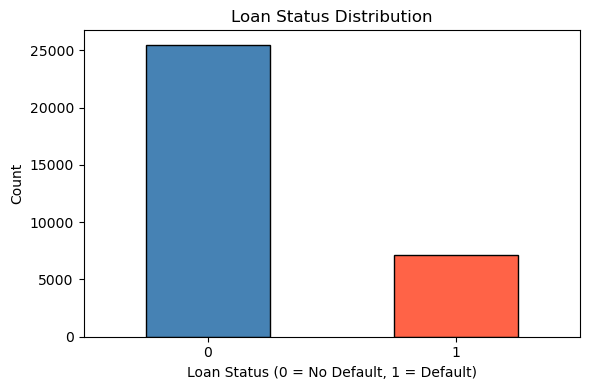

In [4]:
plt.figure(figsize=(6, 4))
df['loan_status'].value_counts().plot(kind='bar', 
                                       color=['steelblue', 'tomato'], 
                                       edgecolor='black')
plt.title('Loan Status Distribution')
plt.xlabel('Loan Status (0 = No Default, 1 = Default)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

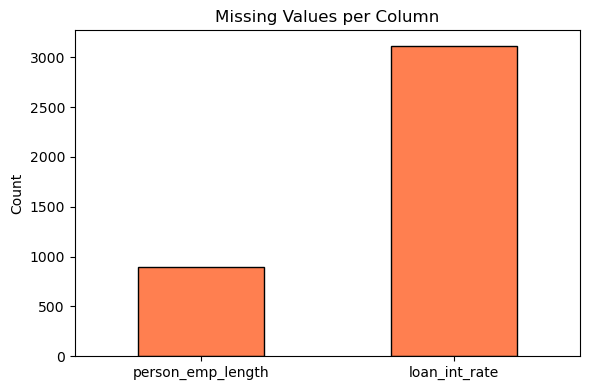

In [5]:
plt.figure(figsize=(6, 4))
missing = df.isnull().sum()
missing = missing[missing > 0]
missing.plot(kind='bar', color='coral', edgecolor='black')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

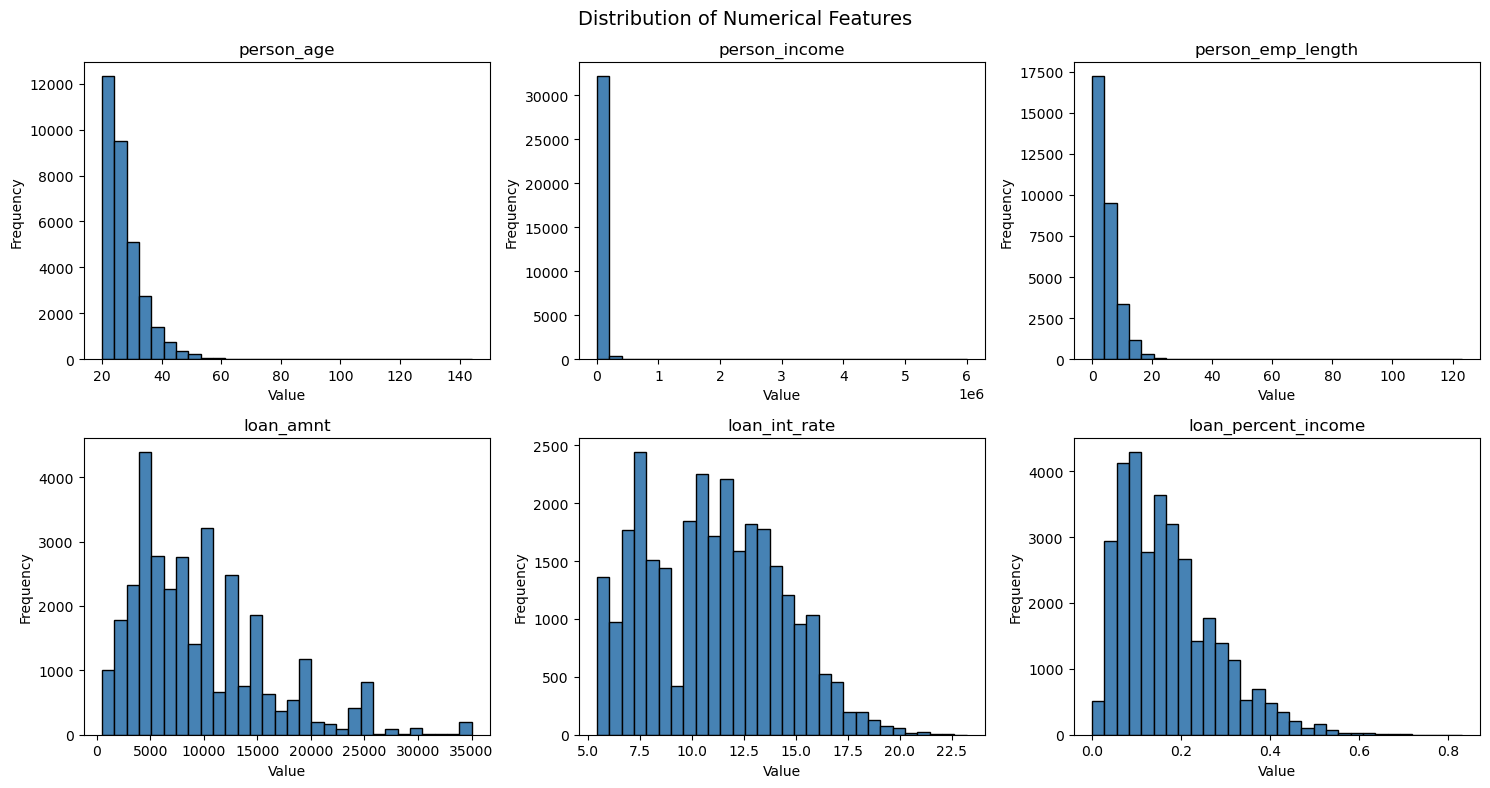

In [6]:
num_cols = ['person_age', 'person_income', 'person_emp_length', 
            'loan_amnt', 'loan_int_rate', 'loan_percent_income']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.suptitle('Distribution of Numerical Features', fontsize=14)
plt.tight_layout()
plt.show()

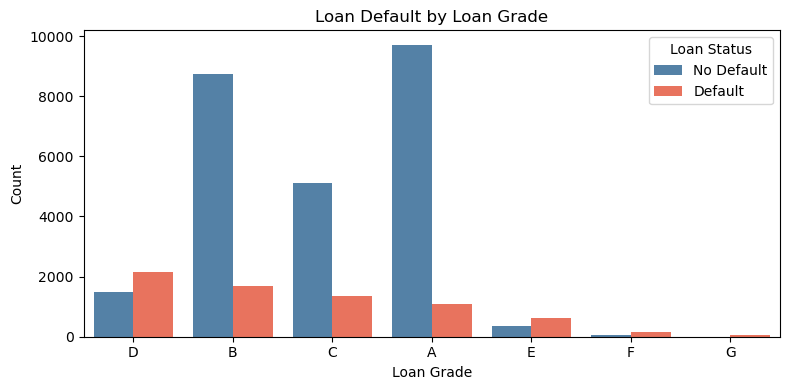

In [7]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='loan_grade', hue='loan_status', 
              palette=['steelblue', 'tomato'])
plt.title('Loan Default by Loan Grade')
plt.xlabel('Loan Grade')
plt.ylabel('Count')
plt.legend(title='Loan Status', labels=['No Default', 'Default'])
plt.tight_layout()
plt.show()

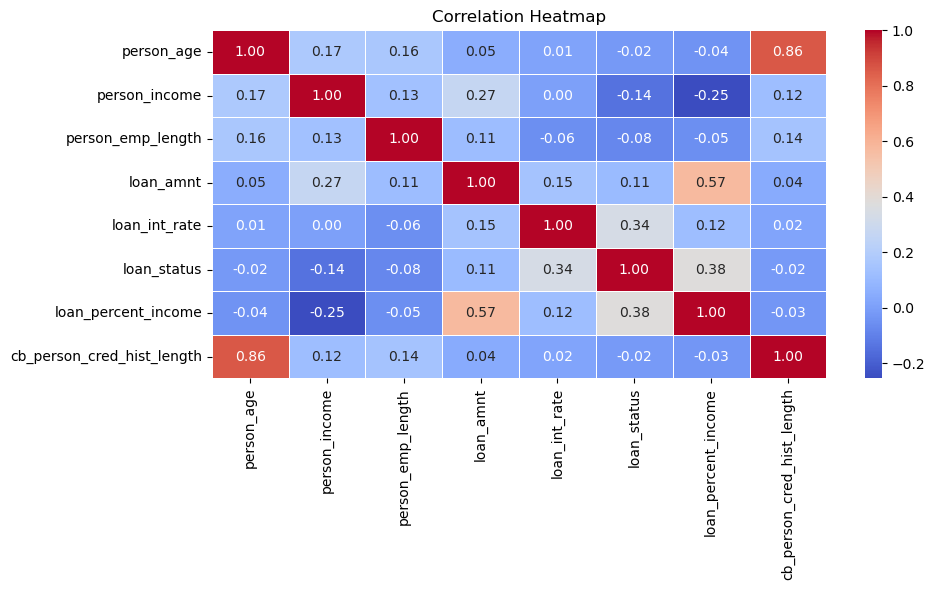

In [8]:
plt.figure(figsize=(10, 6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

In [9]:
# Fill missing values with median
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

# Verify
print('Missing values after filling:')
print(df.isnull().sum())
print('\nTotal missing:', df.isnull().sum().sum())

Missing values after filling:
person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

Total missing: 0


In [10]:
print('Shape before:', df.shape)

# Remove unrealistic ages
df = df[df['person_age'] <= 100]

# Remove unrealistic employment lengths
df = df[df['person_emp_length'] <= 60]

print('Shape after:', df.shape)
print('Rows removed:', 32581 - df.shape[0])

Shape before: (32581, 12)
Shape after: (32574, 12)
Rows removed: 7


In [11]:
cat_cols = ['person_home_ownership', 'loan_intent', 
            'loan_grade', 'cb_person_default_on_file']

le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print('Categorical columns encoded successfully!')
print('\nSample after encoding:')
df[cat_cols].head()

Categorical columns encoded successfully!

Sample after encoding:


,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
1,2,1,1,0
2,0,3,2,0
3,3,3,2,0
4,3,3,2,1
5,2,5,0,0


In [12]:
# Debt-to-income ratio
df['debt_to_income'] = df['loan_amnt'] / (df['person_income'] + 1)

# Income per year of employment
df['income_per_emp_year'] = df['person_income'] / (df['person_emp_length'] + 1)

print('New features created!')
print('\nSample of new features:')
df[['debt_to_income', 'income_per_emp_year']].describe()

New features created!

Sample of new features:


,debt_to_income,income_per_emp_year
count,32574.000000,3.257400e+04
mean,0.170547,1.919883e+04
std,0.107018,2.631111e+04
min,0.000789,5.055000e+02
25%,0.089706,6.800000e+03
50%,0.148144,1.133333e+04
75%,0.229157,2.125000e+04
max,0.829959,2.039784e+06


In [13]:
# Separate features and target
X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Train size:', X_train.shape)
print('Test size :', X_test.shape)
print('\nClass distribution in train:')
print(y_train.value_counts())

Train size: (26059, 13)
Test size : (6515, 13)

Class distribution in train:
loan_status
0    20373
1     5686
Name: count, dtype: int64


In [14]:
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
lr.fit(X_train_scaled, y_train)

print('Logistic Regression trained successfully!')
print('Classes:', lr.classes_)

Logistic Regression trained successfully!
Classes: [0 1]


In [15]:
dt = DecisionTreeClassifier(max_depth=6, class_weight='balanced', random_state=42)
dt.fit(X_train, y_train)

print('Decision Tree trained successfully!')
print('Tree Depth:', dt.get_depth())
print('Number of Leaves:', dt.get_n_leaves())

Decision Tree trained successfully!
Tree Depth: 6
Number of Leaves: 43


In [16]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, 
                             class_weight='balanced', 
                             random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

print('Random Forest trained successfully!')
print('Number of Trees:', rf.n_estimators)

Random Forest trained successfully!
Number of Trees: 100


In [17]:
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('===== Logistic Regression =====')
print(classification_report(y_test, y_pred_lr, 
      target_names=['No Default', 'Default']))
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob_lr).round(4))

===== Logistic Regression =====
              precision    recall  f1-score   support

  No Default       0.92      0.80      0.86      5094
     Default       0.52      0.76      0.62      1421

    accuracy                           0.79      6515
   macro avg       0.72      0.78      0.74      6515
weighted avg       0.84      0.79      0.81      6515

ROC-AUC Score: 0.8516


<Figure size 600x400 with 0 Axes>

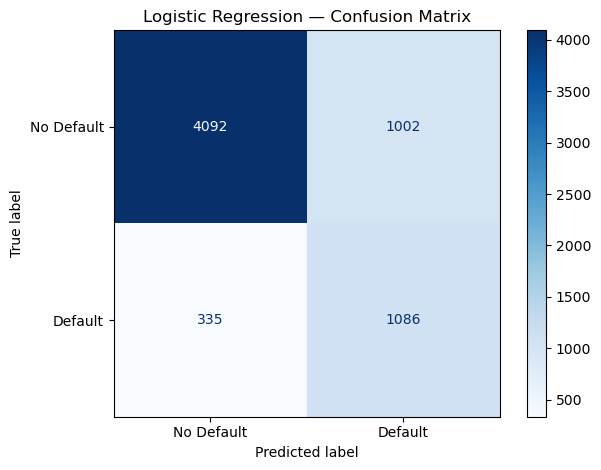

In [18]:
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr,
    display_labels=['No Default', 'Default'],
    cmap='Blues')
plt.title('Logistic Regression — Confusion Matrix')
plt.tight_layout()
plt.show()

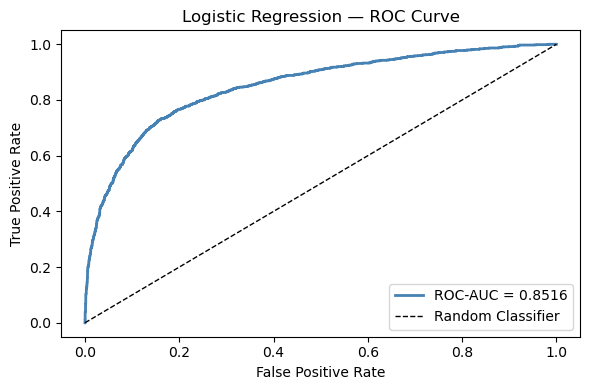

In [19]:
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)
auc_score = roc_auc_score(y_test, y_prob_lr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='steelblue', lw=2, label=f'ROC-AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Logistic Regression — ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

===== Decision Tree =====
              precision    recall  f1-score   support

  No Default       0.93      0.93      0.93      5094
     Default       0.76      0.74      0.75      1421

    accuracy                           0.89      6515
   macro avg       0.84      0.84      0.84      6515
weighted avg       0.89      0.89      0.89      6515

ROC-AUC Score: 0.8929


<Figure size 600x400 with 0 Axes>

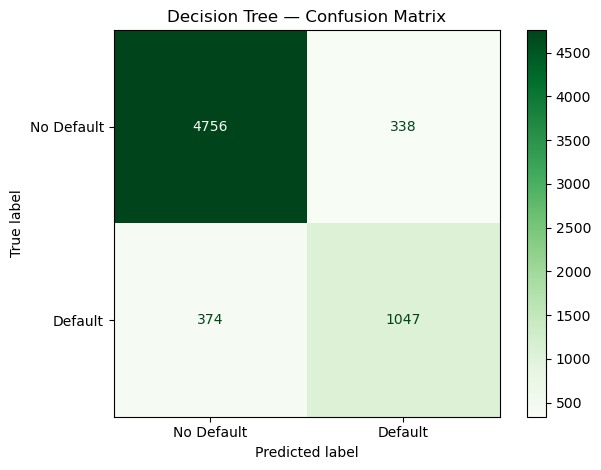

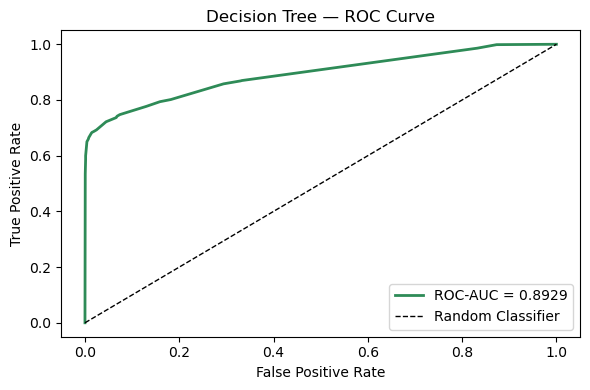

In [20]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print('===== Decision Tree =====')
print(classification_report(y_test, y_pred_dt,
      target_names=['No Default', 'Default']))
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob_dt).round(4))

# Confusion Matrix
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_dt,
    display_labels=['No Default', 'Default'],
    cmap='Greens')
plt.title('Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_dt)
auc_score = roc_auc_score(y_test, y_prob_dt)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='seagreen', lw=2, label=f'ROC-AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Decision Tree — ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

===== Random Forest =====
              precision    recall  f1-score   support

  No Default       0.92      0.96      0.94      5094
     Default       0.84      0.71      0.77      1421

    accuracy                           0.91      6515
   macro avg       0.88      0.84      0.86      6515
weighted avg       0.90      0.91      0.90      6515

ROC-AUC Score: 0.9163


<Figure size 600x400 with 0 Axes>

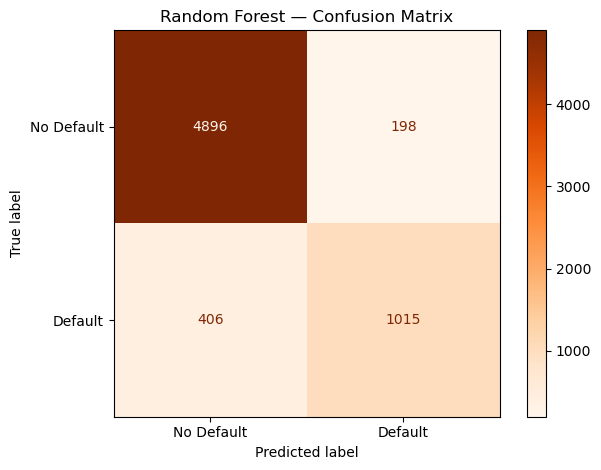

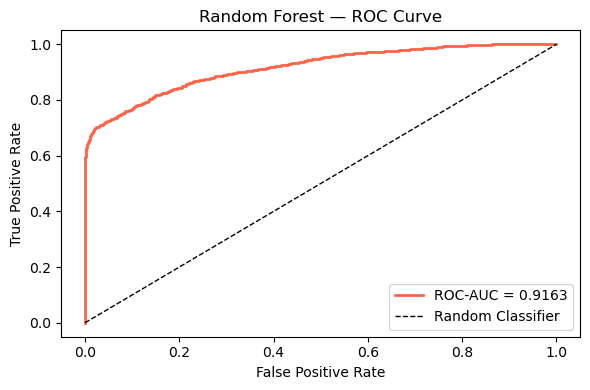

In [21]:
y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

print('===== Random Forest =====')
print(classification_report(y_test, y_pred_rf,
      target_names=['No Default', 'Default']))
print('ROC-AUC Score:', roc_auc_score(y_test, y_prob_rf).round(4))

# Confusion Matrix
plt.figure(figsize=(6, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf,
    display_labels=['No Default', 'Default'],
    cmap='Oranges')
plt.title('Random Forest — Confusion Matrix')
plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob_rf)
auc_score = roc_auc_score(y_test, y_prob_rf)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'ROC-AUC = {auc_score:.4f}')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest — ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

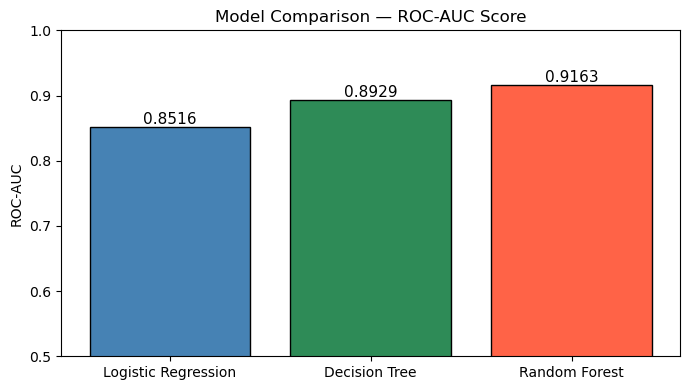

Best Model: Random Forest with ROC-AUC = 0.9163


In [22]:
models = ['Logistic Regression', 'Decision Tree', 'Random Forest']
roc_scores = [
    roc_auc_score(y_test, y_prob_lr),
    roc_auc_score(y_test, y_prob_dt),
    roc_auc_score(y_test, y_prob_rf)
]

plt.figure(figsize=(7, 4))
bars = plt.bar(models, roc_scores, 
               color=['steelblue', 'seagreen', 'tomato'], 
               edgecolor='black')
plt.ylim(0.5, 1.0)
plt.title('Model Comparison — ROC-AUC Score')
plt.ylabel('ROC-AUC')

for bar, score in zip(bars, roc_scores):
    plt.text(bar.get_x() + bar.get_width()/2, 
             bar.get_height() + 0.005,
             f'{score:.4f}', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

best = models[roc_scores.index(max(roc_scores))]
print(f'Best Model: {best} with ROC-AUC = {max(roc_scores):.4f}')

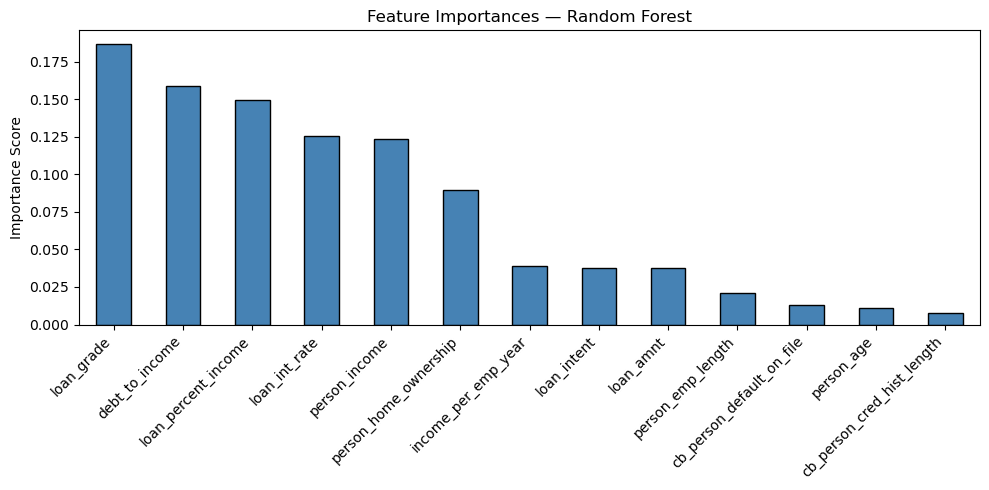


Top 5 Most Important Features:
loan_grade             0.186568
debt_to_income         0.159021
loan_percent_income    0.149534
loan_int_rate          0.125802
person_income          0.123265
dtype: float64


In [23]:
importances = pd.Series(rf.feature_importances_, 
                         index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
importances.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Feature Importances — Random Forest')
plt.ylabel('Importance Score')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 5 Most Important Features:')
print(importances.head())

In [25]:
# Save the best model (Random Forest)
with open('best_model.pkl', 'wb') as f:
    pickle.dump(rf, f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print('best_model.pkl saved!')
print(' scaler.pkl saved!')

best_model.pkl saved!
 scaler.pkl saved!


In [28]:
# Load saved model
with open('best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

print('======= Credit Risk Prediction System =======')
print('Please enter the following details:\n')

# User inputs
person_age = float(input('Enter Age: '))
person_income = float(input('Enter Annual Income: '))

print('\nHome Ownership: 0=MORTGAGE, 1=OTHER, 2=OWN, 3=RENT')
person_home_ownership = float(input('Enter Home Ownership (0/1/2/3): '))

person_emp_length = float(input('Enter Employment Length (years): '))

print('\nLoan Intent: 0=DEBTCONSOLIDATION, 1=EDUCATION, 2=HOMEIMPROVEMENT, 3=MEDICAL, 4=PERSONAL, 5=VENTURE')
loan_intent = float(input('Enter Loan Intent (0-5): '))

print('\nLoan Grade: 0=A, 1=B, 2=C, 3=D, 4=E, 5=F, 6=G')
loan_grade = float(input('Enter Loan Grade (0-6): '))

loan_amnt = float(input('Enter Loan Amount: '))
loan_int_rate = float(input('Enter Interest Rate (e.g. 13.5): '))
loan_percent_income = float(input('Enter Loan Percent of Income (e.g. 0.22): '))

print('\nPrevious Default: 0=No, 1=Yes')
cb_person_default_on_file = float(input('Any Previous Default? (0/1): '))

cb_person_cred_hist_length = float(input('Credit History Length (years): '))

# Auto calculate engineered features
debt_to_income = loan_amnt / (person_income + 1)
income_per_emp_year = person_income / (person_emp_length + 1)

# Build sample
sample = pd.DataFrame([{
    'person_age': person_age,
    'person_income': person_income,
    'person_home_ownership': person_home_ownership,
    'person_emp_length': person_emp_length,
    'loan_intent': loan_intent,
    'loan_grade': loan_grade,
    'loan_amnt': loan_amnt,
    'loan_int_rate': loan_int_rate,
    'loan_percent_income': loan_percent_income,
    'cb_person_default_on_file': cb_person_default_on_file,
    'cb_person_cred_hist_length': cb_person_cred_hist_length,
    'debt_to_income': debt_to_income,
    'income_per_emp_year': income_per_emp_year
}])

# Predict
prediction = loaded_model.predict(sample)[0]
probability = loaded_model.predict_proba(sample)[0][1]

print('\n======= Prediction Result =======')
print(f'Prediction         : {"DEFAULT" if prediction == 1 else "NO DEFAULT"}')
print(f'Default Probability: {probability:.2%}')

======= Credit Risk Prediction System =======
Please enter the following details:



Enter Age:  35
Enter Annual Income:  800000



Home Ownership: 0=MORTGAGE, 1=OTHER, 2=OWN, 3=RENT


Enter Home Ownership (0/1/2/3):  0
Enter Employment Length (years):  10



Loan Intent: 0=DEBTCONSOLIDATION, 1=EDUCATION, 2=HOMEIMPROVEMENT, 3=MEDICAL, 4=PERSONAL, 5=VENTURE


...


Loan Grade: 0=A, 1=B, 2=C, 3=D, 4=E, 5=F, 6=G


Enter Loan Grade (0-6):  0
Enter Loan Amount:  50000
Enter Interest Rate (e.g. 13.5):  7.5
Enter Loan Percent of Income (e.g. 0.22):  0.06



Previous Default: 0=No, 1=Yes


Any Previous Default? (0/1):  0
Credit History Length (years):  10



======= Prediction Result =======
Prediction         : NO DEFAULT
Default Probability: 7.99%
